In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r'D:\Downloads\Final evaluation project resources_Cuvette\Machine Learning resource\hotel_bookings.csv')
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [ ]:
# shape of the dataset
df.shape

(119390, 32)

In [ ]:
# datatypes of all columns in the dataset
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [ ]:
# checking missing or null values 
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [ ]:
# imputing missing values
df['children']=df['children'].fillna(0)
df['country']=df['country'].fillna('unknown')
df['agent']=df['agent'].fillna('NoAgent')
df['has_company']=df['company'].notnull().astype(int)
df['company']=df['company'].fillna(0).astype(int)

In [ ]:
# checking missing or null values
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [74]:
df[['adr','lead_time']].describe()

,adr,lead_time
count,119390.000000,119390.000000
mean,101.831122,104.011416
std,50.535790,106.863097
min,-6.380000,0.000000
25%,69.290000,18.000000
50%,94.575000,69.000000
75%,126.000000,160.000000
max,5400.000000,737.000000


In [ ]:
# detecting outliers using zscore method
from scipy import stats
df['adr_zscore']=stats.zscore(df['adr'])
df['lead_time_zscore']=stats.zscore(df['lead_time'])
adr_outliers=df[abs(df['adr_zscore']) > 3]
lead_time_outliers=df[abs(df['lead_time_zscore']) > 3]
print(f"\n ADR outliers detected: {len(adr_outliers)}")
print(f"\n Lead_time outliers detected: {len(lead_time_outliers)}")



 ADR outliers detected: 1138

 Lead_time outliers detected: 1454


In [ ]:
# detecting outliers using IQR method
def iqr_outliers(series):
    Q1=series.quantile(0.25)
    Q3=series.quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    return series[(series<lower) | (series>upper)]
adr_iqr_outliers = iqr_outliers(df['adr'])
lead_time_iqr_outliers = iqr_outliers(df['lead_time'])
print(f"\n ADR outliers (IQR method): {len(adr_iqr_outliers)}")
print(f"\n Lead_time outliers (IQR method): {len(lead_time_iqr_outliers)}")



 ADR outliers (IQR method): 3793

 Lead_time outliers (IQR method): 3005


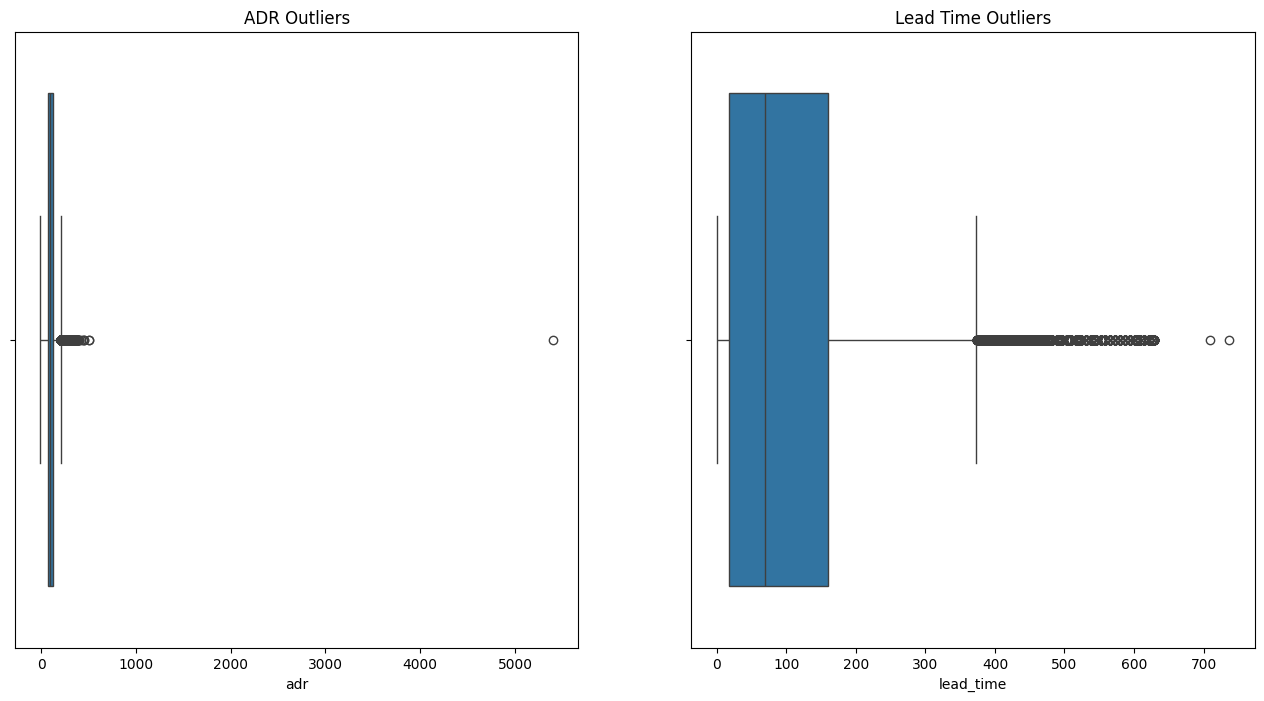

In [ ]:
# visualizing ADR outliers and Lead time outliers using boxplot
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
sns.boxplot(x=df['adr'])
plt.title("ADR Outliers")
plt.subplot(1,2,2)
sns.boxplot(x=df['lead_time'])
plt.title("Lead Time Outliers")
plt.show()

In [ ]:

# capping outliers(winsorisation)
def cap_outliers(series):
    Q1=series.quantile(0.25)
    Q3=series.quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    return np.where(series<lower,lower,np.where(series>upper,upper,series))
df['adr_capped'] = cap_outliers(df['adr'])
df['lead_time_capped'] = cap_outliers(df['lead_time'])
print("\n ADR before capping:", df['adr'].describe())
print("\n ADR after capping:", df['adr_capped'].describe())
print("\n Lead_time before capping:", df['lead_time'].describe())
print("\n Lead_time after capping:", df['lead_time_capped'].describe())


 ADR before capping: count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

 ADR after capping: count    119390.000000
mean        100.659305
std          44.688946
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max         211.065000
Name: adr_capped, dtype: float64

 Lead_time before capping: count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

 Lead_time after capping: count    119390.000000
mean        102.229157
std         101.158934
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         373.000000
Name: lead_time_capped, dtype: float64


In [79]:
# converting datatypes
df['children'] = df['children'].astype(int)
df['agent'] = df['agent'].astype('category')
df['company'] = df['company'].astype('category')
categorical_cols = ['hotel','meal','country','market_segment','distribution_channel','reserved_room_type',
                    'assigned_room_type','deposit_type','customer_type','reservation_status','arrival_date_month'
]
df[categorical_cols] = df[categorical_cols].astype('category')
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

In [ ]:
# checking datatypes of all columns in the dataset
df.dtypes

hotel                                   category
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                      category
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                   int64
babies                                     int64
meal                                    category
country                                 category
market_segment                          category
distribution_channel                    category
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                      category
assigned_room_type  

In [ ]:
# scaling numeric columns using robust scaler 
from sklearn.preprocessing import RobustScaler
numeric_cols=df.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols=[c for c in numeric_cols if c!='is_canceled']  
scaler=RobustScaler()
df[numeric_cols]=scaler.fit_transform(df[numeric_cols])

In [ ]:
# categorizing lead_time column
conditions = [(df['lead_time'] < 30),(df['lead_time'] >= 30) & (df['lead_time'] < 90),(df['lead_time'] >= 90)]
choices = ['Short', 'Medium', 'Large']
df['lead_time_category'] = np.select(conditions, choices, default='Unknown')

In [83]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,has_company,adr_zscore,lead_time_zscore,adr_capped,lead_time_capped,lead_time_category
0,Resort Hotel,0,1.922535,-1.0,July,-0.045455,-1.000000,-0.5,-1.0,0.0,...,0.0,0.0,Check-Out,2015-07-01,0.0,-1.667695,1.922535,-1.667695,1.922535,Short
1,Resort Hotel,0,4.704225,-1.0,July,-0.045455,-1.000000,-0.5,-1.0,0.0,...,0.0,0.0,Check-Out,2015-07-01,0.0,-1.667695,4.704225,-1.667695,2.140845,Short
2,Resort Hotel,0,-0.436620,-1.0,July,-0.045455,-1.000000,-0.5,-0.5,-1.0,...,0.0,0.0,Check-Out,2015-07-02,0.0,-0.345177,-0.436620,-0.345177,-0.436620,Short
3,Resort Hotel,0,-0.394366,-1.0,July,-0.045455,-1.000000,-0.5,-0.5,-1.0,...,0.0,0.0,Check-Out,2015-07-02,0.0,-0.345177,-0.394366,-0.345177,-0.394366,Short
4,Resort Hotel,0,-0.387324,-1.0,July,-0.045455,-1.000000,-0.5,0.0,0.0,...,0.0,1.0,Check-Out,2015-07-03,0.0,0.060395,-0.387324,0.060395,-0.387324,Short
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,-0.323944,1.0,August,0.318182,0.933333,0.5,1.5,0.0,...,0.0,0.0,Check-Out,2017-09-06,0.0,0.027597,-0.323944,0.027597,-0.323944,Short
119386,City Hotel,0,0.232394,1.0,August,0.318182,1.000000,0.5,1.5,1.0,...,0.0,2.0,Check-Out,2017-09-07,0.0,2.307441,0.232394,2.054135,0.232394,Short
119387,City Hotel,0,-0.246479,1.0,August,0.318182,1.000000,0.5,1.5,0.0,...,0.0,4.0,Check-Out,2017-09-07,0.0,1.113296,-0.246479,1.113296,-0.246479,Short
119388,City Hotel,0,0.281690,1.0,August,0.318182,1.000000,0.5,1.5,0.0,...,0.0,0.0,Check-Out,2017-09-07,0.0,0.173250,0.281690,0.173250,0.281690,Short


In [84]:
df['lead_time_category'].value_counts()

lead_time_category
Short    119390
Name: count, dtype: int64

In [ ]:
# identifying high_risk_customers
canceled_df = df[df['is_canceled'] == 1]
cancel_counts = canceled_df.groupby('agent').size().reset_index(name='cancel_count')
high_risk_customers = cancel_counts[cancel_counts['cancel_count'] > 1]
print(high_risk_customers)

       agent  cancel_count
0        1.0          5280
1        2.0            34
2        3.0           771
3        4.0            31
4        5.0           149
..       ...           ...
322    493.0             5
323    495.0            50
327    509.0             2
331    531.0            46
333  NoAgent          4030

[191 rows x 2 columns]


C:\Users\immad\AppData\Local\Temp\ipykernel_10800\1179899720.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancel_counts = canceled_df.groupby('agent').size().reset_index(name='cancel_count')


In [ ]:
# identifying most_frequent_guests
booking_counts = df.groupby('agent').size().reset_index(name='booking_count')
most_frequent_guests = booking_counts.sort_values(by='booking_count', ascending=False)
print(most_frequent_guests.head(10))

       agent  booking_count
8        9.0          31961
333  NoAgent          16340
173    240.0          13922
0        1.0           7191
13      14.0           3640
6        7.0           3539
5        6.0           3290
182    250.0           2870
174    241.0           1721
26      28.0           1666


C:\Users\immad\AppData\Local\Temp\ipykernel_10800\3857908856.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  booking_counts = df.groupby('agent').size().reset_index(name='booking_count')


In [ ]:
# identifying seasonal_trends
seasonal_trends = df.groupby(['hotel', 'arrival_date_month']).size().reset_index(name='booking_count')
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July','August', 'September', 'October', 'November', 'December']
seasonal_trends['arrival_date_month'] = pd.Categorical(seasonal_trends['arrival_date_month'], categories=month_order, ordered=True)
seasonal_trends = seasonal_trends.sort_values(['hotel', 'arrival_date_month'])
print(seasonal_trends)

           hotel arrival_date_month  booking_count
4     City Hotel            January           3736
3     City Hotel           February           4965
7     City Hotel              March           6458
0     City Hotel              April           7480
8     City Hotel                May           8232
6     City Hotel               June           7894
5     City Hotel               July           8088
1     City Hotel             August           8983
11    City Hotel          September           7400
10    City Hotel            October           7605
9     City Hotel           November           4357
2     City Hotel           December           4132
16  Resort Hotel            January           2193
15  Resort Hotel           February           3103
19  Resort Hotel              March           3336
12  Resort Hotel              April           3609
20  Resort Hotel                May           3559
18  Resort Hotel               June           3045
17  Resort Hotel               

C:\Users\immad\AppData\Local\Temp\ipykernel_10800\3883235049.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal_trends = df.groupby(['hotel', 'arrival_date_month']).size().reset_index(name='booking_count')


In [ ]:
# removing unnecessary columns
drop_cols = ['reservation_status', 'reservation_status_date','company', 'adr_zscore', 'lead_time_zscore', 'lead_time_category']
df = df.drop(columns=drop_cols, errors='ignore')

In [ ]:
# converting datatypes
df['arrival_date_year'] = df['arrival_date_year'].astype(int)
df['adults'] = df['adults'].fillna(0).astype(int)
df['children'] = df['children'].fillna(0).astype(int)
df['babies'] = df['babies'].fillna(0).astype(int)
df['is_repeated_guest'] = df['is_repeated_guest'].astype(int)

In [90]:
df['adr'] = df['adr'].clip(lower=0, upper=df['adr'].quantile(0.99))
df['lead_time'] = df['lead_time'].clip(upper=df['lead_time'].quantile(0.99))

In [91]:
top_countries = df['country'].value_counts().nlargest(10).index
df['country'] = df['country'].apply(lambda x: x if x in top_countries else 'Other')
top_agents = df['agent'].value_counts().nlargest(20).index
df['agent'] = df['agent'].apply(lambda x: x if x in top_agents else 'Other')

In [ ]:
# encoding categorical columns using get_dummies
df = pd.get_dummies(df, drop_first=True)
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
# splitting the dataset into train and test sets
from sklearn.model_selection import train_test_split
X=df.drop("is_canceled",axis=1)
y=df["is_canceled"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
print("Training set shape:",X_train.shape)
print("Testing set shape:",X_test.shape)

Training set shape: (95512, 102)
Testing set shape: (23878, 102)


In [ ]:
# training models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
models = {'Logistic Regression': LogisticRegression(max_iter=1000),'Decision Tree': DecisionTreeClassifier(),
          'Random Forest': RandomForestClassifier(),'Gradient Boosting': GradientBoostingClassifier(),'Support Vector Machine': SVC()}
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

Logistic Regression trained.
Decision Tree trained.
Random Forest trained.
Gradient Boosting trained.
Support Vector Machine trained.


In [95]:
from sklearn.model_selection import RandomizedSearchCV
subset_size = min(10000, len(X_train))
X_sample = X_train.sample(n=subset_size, random_state=42)
y_sample = y_train.loc[X_sample.index]
param_distributions = {'Logistic Regression': {'C': np.logspace(-4, 4, 10),'solver': ['liblinear','saga']},
    'Decision Tree': {'max_depth': [None, 10, 20],'min_samples_split': [2, 5],'min_samples_leaf': [1, 2]},
    'Random Forest': {'n_estimators': [100, 200, 300],'max_depth': [None, 10, 20],'min_samples_split': [2, 5],'min_samples_leaf': [1, 2],'bootstrap': [True]},
    'Gradient Boosting': {'n_estimators': [100, 200],'learning_rate': [0.05, 0.1],'max_depth': [3, 4],'min_samples_split': [2, 5]}}

models = {'Logistic Regression': LogisticRegression(max_iter=1000),'Decision Tree': DecisionTreeClassifier(),
          'Random Forest': RandomForestClassifier(),'Gradient Boosting': GradientBoostingClassifier()}
best_models = {}
for name, model in models.items():
    print(f"Running RandomizedSearchCV for {name} on sampled data...")
    rscv = RandomizedSearchCV(model,param_distributions[name],n_iter=8,cv=3,verbose=1,n_jobs=4,random_state=42,scoring='accuracy')
    rscv.fit(X_sample, y_sample)
    print(f"Best parameters for {name}: {rscv.best_params_}")
    print(f"Best cross-validation accuracy: {rscv.best_score_:.4f}")
    best_models[name] = rscv.best_estimator_
print("Hyperparameter tuning completed for sampled data.")


Running RandomizedSearchCV for Logistic Regression on sampled data...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters for Logistic Regression: {'solver': 'liblinear', 'C': np.float64(0.3593813663804626)}
Best cross-validation accuracy: 0.8171
Running RandomizedSearchCV for Decision Tree on sampled data...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters for Decision Tree: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
Best cross-validation accuracy: 0.8247
Running RandomizedSearchCV for Random Forest on sampled data...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters for Random Forest: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': True}
Best cross-validation accuracy: 0.8581
Running RandomizedSearchCV for Gradient Boosting on sampled data...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters for Gradient Boosti

In [96]:
param_distributions_svm = {'C': np.logspace(-2, 2, 6),'kernel': ['rbf', 'linear'],'gamma': ['scale']}
svm = SVC()
print("Running RandomizedSearchCV for SVM on sampled data...")
rscv_svm = RandomizedSearchCV(svm,param_distributions_svm,n_iter=8,cv=3,verbose=1,n_jobs=4,random_state=42,scoring='accuracy')
rscv_svm.fit(X_sample, y_sample)
print(f"Best parameters for SVM: {rscv_svm.best_params_}")
print(f"Best cross-validation accuracy: {rscv_svm.best_score_:.4f}")
best_svm_model = rscv_svm.best_estimator_

Running RandomizedSearchCV for SVM on sampled data...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters for SVM: {'kernel': 'rbf', 'gamma': 'scale', 'C': np.float64(100.0)}
Best cross-validation accuracy: 0.8403


In [ ]:
# evaluating models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
results = []
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Performance Metrics for {name}:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 60)
    results.append({'Model': name,'Accuracy': acc,'Precision': prec,'Recall': rec,'F1 Score': f1})


Performance Metrics for Logistic Regression:
Accuracy:  0.8198
Precision: 0.8077
Recall:    0.6742
F1 Score:  0.7349
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.86     15033
           1       0.81      0.67      0.73      8845

    accuracy                           0.82     23878
   macro avg       0.82      0.79      0.80     23878
weighted avg       0.82      0.82      0.82     23878

Confusion Matrix:
[[13613  1420]
 [ 2882  5963]]
------------------------------------------------------------
Performance Metrics for Decision Tree:
Accuracy:  0.8414
Precision: 0.8270
Recall:    0.7232
F1 Score:  0.7717
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88     15033
           1       0.83      0.72      0.77      8845

    accuracy                           0.84     23878
   macro avg       0.84      0.82      0.83     23878
weighted avg     

In [ ]:
# evaluating models
y_pred_svm = best_svm_model.predict(X_test)
print(f"Performance Metrics for Support Vector Machine:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_svm):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print("-" * 60)

Performance Metrics for Support Vector Machine:
Accuracy:  0.8480
Precision: 0.8466
Recall:    0.7201
F1 Score:  0.7782
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.92      0.88     15033
           1       0.85      0.72      0.78      8845

    accuracy                           0.85     23878
   macro avg       0.85      0.82      0.83     23878
weighted avg       0.85      0.85      0.85     23878

Confusion Matrix:
[[13879  1154]
 [ 2476  6369]]
------------------------------------------------------------


In [ ]:
# comparing different models metrics
best_models['Support Vector Machine'] = best_svm_model
results = []
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Performance Metrics for {name}:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 60)
    results.append({'Model': name,'Accuracy': acc,'Precision': prec,'Recall': rec,'F1 Score': f1})
    results_df = pd.DataFrame(results)

Performance Metrics for Logistic Regression:
Accuracy:  0.8198
Precision: 0.8077
Recall:    0.6742
F1 Score:  0.7349
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.86     15033
           1       0.81      0.67      0.73      8845

    accuracy                           0.82     23878
   macro avg       0.82      0.79      0.80     23878
weighted avg       0.82      0.82      0.82     23878

Confusion Matrix:
[[13613  1420]
 [ 2882  5963]]
------------------------------------------------------------
Performance Metrics for Decision Tree:
Accuracy:  0.8414
Precision: 0.8270
Recall:    0.7232
F1 Score:  0.7717
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88     15033
           1       0.83      0.72      0.77      8845

    accuracy                           0.84     23878
   macro avg       0.84      0.82      0.83     23878
weighted avg     

In [100]:
cv_results = []
for name, model in best_models.items():
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='f1', n_jobs=4)
    print(f"Cross-Validation results for {name}:")
    print(f"Mean F1 Score: {cv_scores.mean():.4f}")
    print(f"Standard Deviation: {cv_scores.std():.4f}")
    print("-" * 60)
    cv_results.append({'Model': name,'CV Mean F1 Score': cv_scores.mean(),'CV Std Dev': cv_scores.std()})
    cv_results_df = pd.DataFrame(cv_results)

Cross-Validation results for Logistic Regression:
Mean F1 Score: 0.5638
Standard Deviation: 0.0930
------------------------------------------------------------
Cross-Validation results for Decision Tree:
Mean F1 Score: 0.5314
Standard Deviation: 0.0822
------------------------------------------------------------
Cross-Validation results for Random Forest:
Mean F1 Score: 0.4451
Standard Deviation: 0.1161
------------------------------------------------------------
Cross-Validation results for Gradient Boosting:
Mean F1 Score: 0.4504
Standard Deviation: 0.0751
------------------------------------------------------------
Cross-Validation results for Support Vector Machine:
Mean F1 Score: 0.4380
Standard Deviation: 0.0959
------------------------------------------------------------


In [101]:
comparison_df = pd.merge(results_df, cv_results_df, on='Model')
comparison_df = comparison_df.sort_values(by='F1 Score', ascending=False)
print("Model Performance Comparison (Test vs Cross-Validation):")
print(comparison_df)

Model Performance Comparison (Test vs Cross-Validation):
                    Model  Accuracy  Precision    Recall  F1 Score  \
3       Gradient Boosting  0.861169   0.844849  0.765856  0.803416   
2           Random Forest  0.863975   0.874883  0.738383  0.800858   
4  Support Vector Machine  0.847977   0.846604  0.720068  0.778226   
1           Decision Tree  0.841444   0.827020  0.723233  0.771653   
0     Logistic Regression  0.819834   0.807666  0.674166  0.734903   

   CV Mean F1 Score  CV Std Dev  
3          0.450422    0.075090  
2          0.445108    0.116077  
4          0.438030    0.095851  
1          0.531387    0.082243  
0          0.563804    0.093013  


In [ ]:
# identifying the best model
best_model_row = comparison_df.sort_values(by='F1 Score', ascending=False).iloc[0]
best_model_name = best_model_row['Model']
print(f"\nBest model based on test F1 Score: {best_model_name}")
print("\nFull performance metrics for the best model:")
print(best_model_row)
best_model = best_models[best_model_name]


Best model based on test F1 Score: Gradient Boosting

Full performance metrics for the best model:
Model               Gradient Boosting
Accuracy                     0.861169
Precision                    0.844849
Recall                       0.765856
F1 Score                     0.803416
CV Mean F1 Score             0.450422
CV Std Dev                    0.07509
Name: 3, dtype: object
